# MVP — Machine Learning & Analytics

**Nome:** André Luiz de Oliveira Marques Pelegrino  
**Matrícula:** 4052025002026  
**Data:** 05/06/2026  
**Dataset:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/data?select=train.csv)  
**Tipo de problema:** Classificação

**LINK DO COLLAB:** https://colab.research.google.com/drive/1PCMRYVIGB8dzt2C2CePojm7yDeUJ1dPj

## Checklist do MVP
| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | x |
| Dataset descrito, com fonte, atributos e restrições | x |
| Dataset carregado por URL pública ou fonte diretamente acessível | x |
| Análise exploratória objetiva, conectada à modelagem | x |
| Divisão adequada em treino/teste e, se aplicável, validação | x |
| Prevenção de vazamento de dados | x |
| Tratamentos de dados justificados | x |
| Pipeline ou sequência reprodutível de pré-processamento | x |
| Modelo baseline definido | x |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | x |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | x |
| Avaliação com métricas coerentes com o problema | x |
| Discussão de overfitting/underfitting, limitações e melhorias | x |
| Código limpo, organizado e executável do início ao fim | x |
| Conclusão conectada ao objetivo inicial | x |



# 1. Definição do problema


## 1.1 Descrição do problema

Esse projeto ultiliza os dados do dataset de Passageiros do titanic, que reune informações sobre caracteristicas das pessoas que estavam dentro do barco no momento do famoso acidente.

Ele inclui dados relacionados ao sexo, idade, relacionamento dos passageiros, classe social, local de embarcação, quanto custou a passagem do barco, entre outros atributos. O objetivo principal compreender os padrões das pessoas que sobreviveram a esse evento e montar um modelo de aprendizado de maquina que consiga classificar baseado em certos atributos do dataset, se uma pessoa sobreviveria ou não a tragedia do titanic.

Os interessados nesse projeto incluem estudantes de Data Science e Machine Learning, que utilizam este problema clássico para validar algoritmos de classificação, e pesquisadores acadêmicos focados em estatística aplicada a eventos históricos e segurança de transportes. A relevância desse projeto,reside na capacidade de demonstrar como  a análise de correlação podem extrair conhecimento valioso de eventos complexos.
  Além disso, revela como fatores fisicos e socioeconômicos influenciaram as chances de sobrevivência em um cenário de crise real, que talvez pode ser utlilizado como exemplo caso um acidente de magnitude semelhante passe a acontecer.


## 1.2 Objetivo do MVP
**Objetivo deste trabalho:**  
> O objetivo deste MVP é construir e avaliar um modelo de Machine Learning para prever se uma pessoa sobreviveria ou não a tragedia do titanic, a partir de preditores como sexo, idade e classe social. comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** O Tipo do problema que queremos resolver é de classificação, pois queremos separar as pessoas em dois grupos, classificando elas em numeros binarios, ou seja, 0 - Não sobreviveu, 1- Sobreviveu. A principio, esse sera o atributo target do projeto.




## 1.4 Premissas, hipóteses e critérios de sucesso
Para verificar quais dados são importantes para o projeto, algumas hipoteses serão respondidas e alguns criterios serão definidos para o sucesso do estudo.

**Hipóteses iniciais:**
1. Os passageiros de primeira classe sobreviveram mais do que os passageiros de outras classes?

2. Existe correlação positiva entre a idade do passageiro e a porcentagem de sobrevivencia ?

3. A presença de familiares a bordo, medida pelas variáveis de irmãos/cônjuges e pais/filhos, facilitou ou dificultou o processo de sobrevivência dos passageiros?

4. O porto onde o passageiro embarcou (Cherbourg, Queenstown ou Southampton) influenciou indiretamente na sobrevivência, possivelmente devido à distribuição de classes sociais predominantes em cada local de partida?

5. A porcentagem de sobrevivencia das mulheres foi maior do que a dos homens?

6. a tarifa(fare) paga pelo passageiro, influenciou diratamente na sobrevivencia?

**Critérios de sucesso:**
- Metrica principal: F1-score
- Resultado minimo esperado: Superar a baseline em pelo menos 50%
- Restrição prática: Interpretabilidade. Como o objetivo é entender os fatores do naufrágio, o modelo deve permitir identificar claramente quais variáveis  foram as mais importantes para a tomada de decisão.
--------------------------------------

# 2. Ambiente, bibliotecas e reprodutibilidade

Segue Abaixo as bibliotecas importadas para a realização desse projeto:


In [ ]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler ,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint


warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


## 2.1 Bibliotecas adicionais que estão sendo usadas



In [ ]:

!pip install -q imbalanced-learn xgboost lightgbm catboost # modelos extras
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Nome do dataset junto com o link da fonte:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/data?select=train.csv)


**por que esse dataset foi escolhido:** Esse dataset foi escolhido pois é um conjunto de dados que pode ser usado para a resolução de um problema de classificação binario, é um dataset complexo que tras alguns dados faltantes, sendo assim possivel o tratamento de missings e devido a facilidade de manuseio.

**quais restrições ou condições foram consideradas:** Durante a análise do dataset, foi possivel identificar restrições importantes em relação à integridade dos dados, esse dataset possui uma variavel que possui muitas missings, a variavel cabin, esta possui 687 valores ausentes, que serão tratados posteriormente.
É importante indicar que esse dataset possui 891 observações, ou seja, possui poucos dados e deve permitir o treinamento rapido do modelo de Machine Learning.

**se há questões de ética, privacidade, confidencialidade ou licença:**
 Os dados referem-se a passageiros de um evento histórico ocorrido em 1912. Sendo registros de domínio público, não há infrações à LGPD ou leis de privacidade

## 3.2 Carga dos dados

Abaixo sera realizado a carga dos dados do dataset titanic:


In [ ]:
# === Carga dos dados ===
url = "https://raw.githubusercontent.com/AndreLOMP/MVP-Titanic-Binary-Classification/refs/heads/main/Dataset_Titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3.3 Visão geral do dataset

Esta seção apresenta um resumo/Visão geral dos dados presentes no dataset titanic.

**Quantidade de linhas e colunas:** O conjunto de dados é composto por 891 observações (linhas) e 12 variáveis/Atributos (colunas).

**Tipos dos atributos:** A base possui uma combinação de tipos de dados numericos, categoricos e em formato de texto, as variaveis do dataset são bem variadas, representando sexo, idade, classe do passageiro, relacionamento entre os passageiros, entre outros que vão estar listados no proximo bloco.

**Valores ausentes no dataset:** Existem três colunas com dados faltantes que necessitam de atenção:
1. **Cabin**: É a variável mais crítica, com 687 valores ausentes
2. **Age**: Apresenta 177 valores ausentes
3. **Embarked**: Possui apenas 2 valores ausentes
(esses dados serão validos no bloco abaixo onde é possivel ver as missings do dataset)

**Duplicatas:** Nenhuma linha duplicada foi encontrada no dataset, garantindo que cada registro represente um unico passageiro;

**Colunas de ID e variáveis que não irão participar do modelo:** Para a construção do modelo preditivo inicial, as seguintes colunas devem ser avaliadas para exclusão ou tratamento especial:
  1. **PassengerId**: Funciona apenas como um identificador numérico, e não um valor preditivo.
  2. **Name e Ticket**: São os valores que mais variam, e não tem um valor de classificação muito alto, o que significa que essas variaveis não possuem valor no projeto.
  3. **Cabin**: Devido ao excessivo volume de dados ausentes,seu uso direto é inviável e pode prejudicar o modelo.

**Descrição do target:** A variável alvo é a **Survived**, uma variável categórica binária onde 0 Representa o passageiro que não sobreviveu e
1 Representa o passageiro que sobreviveu.


In [ ]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (891, 12)

Tipos de dados:


,tipo
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
#valores importante como desvio padrão, maximo, minimo, media e mediana dos atributos do dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
print("\nDuplicatas:", df.duplicated().sum())


Duplicatas: 0


In [ ]:
display(df.sample(5, random_state=SEED))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


## 3.4 Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| PassengerId| numérica|ID do passageiro | Não | É apenas um indice, nao tem valor preditivo |
| Pclass|categórica| Classe do passageiro(1ª,2ª ou 3ª)| Sim | Pode ter correlação com a sobrevivencia |
| Name| Texto |Nome do Passageiro | Não |Não tem valor estatistico |
| Sex | categórica| Genero do passageiro | Sim |Pode ter correlação com a % de sobrevivencia |
| Age  | numérica| Idade do passageiro | Sim | Importante para identificar grupos prioritários|
| Sibsp | Numerica |Nº de irmaos ou conjuges no navio | Sim | identificar a estrutura familiar e seu impacto no resgate |
| Parch |Numerica | Nº de pais ou filhos no navio | Sim | Complementa a análise de vínculos familiares iniciada pela variável SibSp |
| Ticket | Texto | Ticket da viagem | Não | Muita variação, e sem valor pro projeto |
| Embarked | categórica |onde o passageiro embarcou| Sim | pode servir para ver a distribuição de classe social |
| Fare |numerica| valor da tarifa paga | Sim | Pode representar alta correlação com a sobrevivencia dos passageiros |
| Cabin|texto | numero da cabine | Não | Possui muitas missings, dando um valor estatistico não tao preciso |
| Survived | alvo | Se o passageiro sobreviveu ou nao | alvo | Variável dependente de outros atributos |

# 4. Análise exploratória dos dados Inicial

A análise exploratória deve ser objetiva e conectada ao problema.

Nesta etapa de Análise de Dados Exploratória sobre o dataset Titanic, sera feito uma leitura de graficos para entender mais sobre o dataset e sobre informações importantes dos atributos como distribuição, relações entre elas, estatisticas descritivas do dataset e mais detalhes sobre os dados no geral, o que é crucial para as etapas subsequentes de pré-processamento e modelagem. O intuito desse bloco é fazer uma analise exploratoria geral do dataset, após o término da analise inicial, sera realizado a analise exploratória especifica das hipóteses criadas no bloco 1.4 - "Premissas, hipóteses e critérios de sucesso"

In [ ]:
#Distribuição do atributo target "Survived" bruto e em percentual
TARGET = "Survived"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))

Distribuição do target:


,contagem
Survived,
0,549
1,342


,percentual
Survived,
0,61.62
1,38.38



Distribuição de variáveis numéricas relevantes:


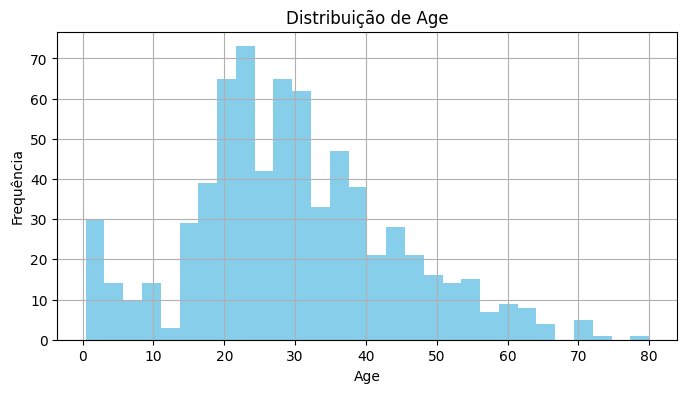

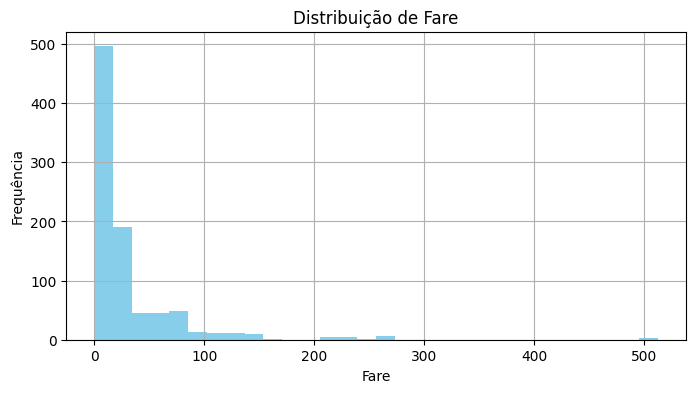

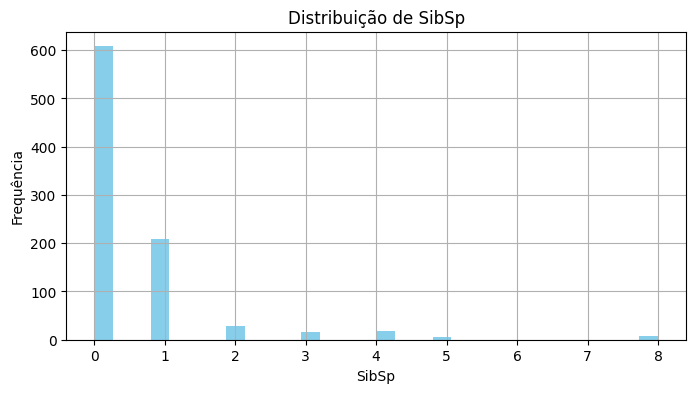

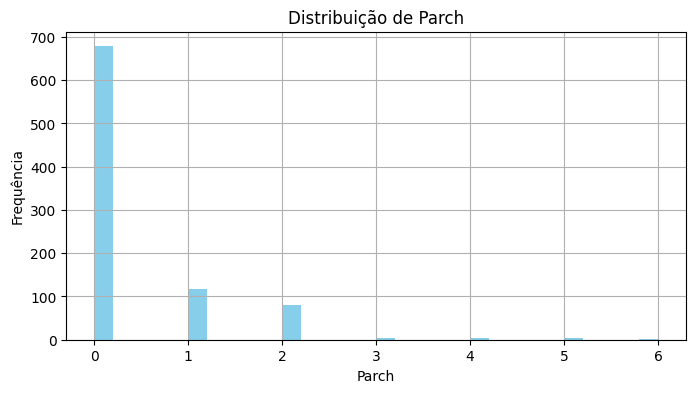


Distribuição de variáveis categóricas relevantes:


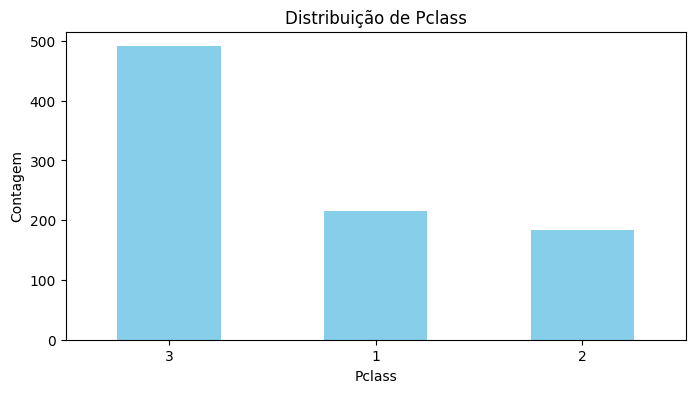

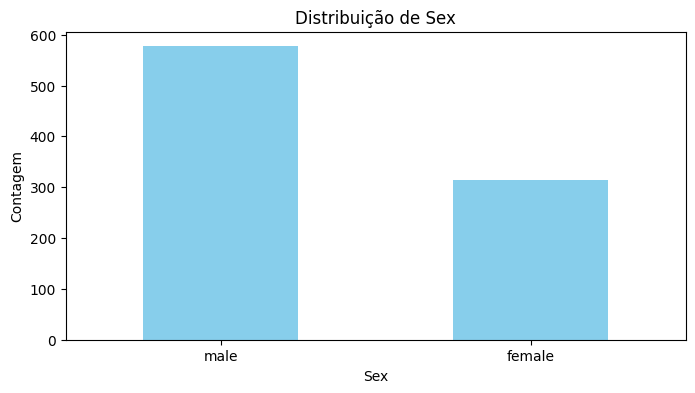

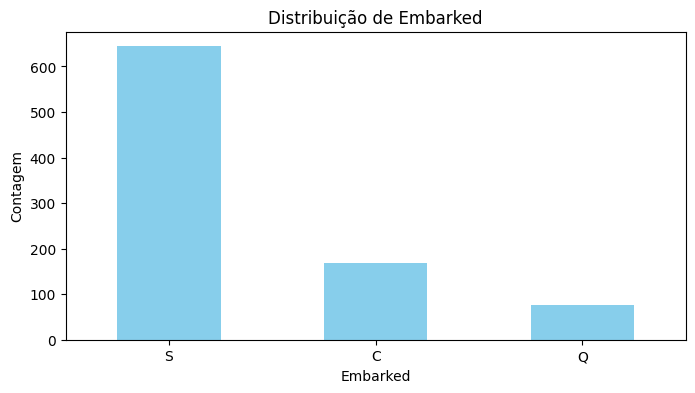

In [ ]:
#Graficos de barra para verificação de distribuição dos atributos do dataset
print("\nDistribuição de variáveis numéricas relevantes:")
for col in ['Age', 'Fare', 'SibSp','Parch']:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=30, color='skyblue')
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

print("\nDistribuição de variáveis categóricas relevantes:")
for col in ['Pclass', 'Sex', 'Embarked']:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind="bar", color='skyblue')
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.xticks(rotation=0)
    plt.show()


Distribuição de variáveis numéricas relevantes (em azul claro):


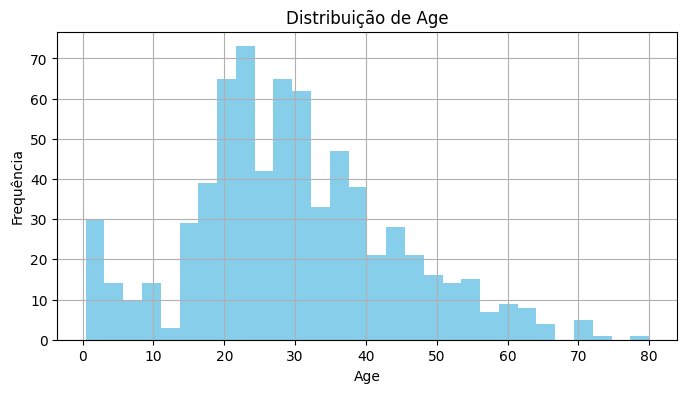

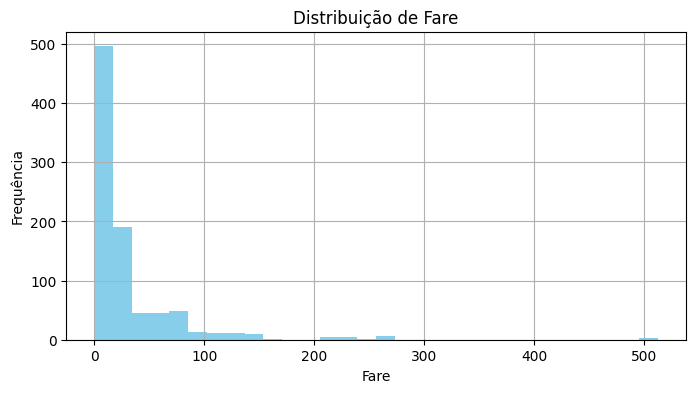

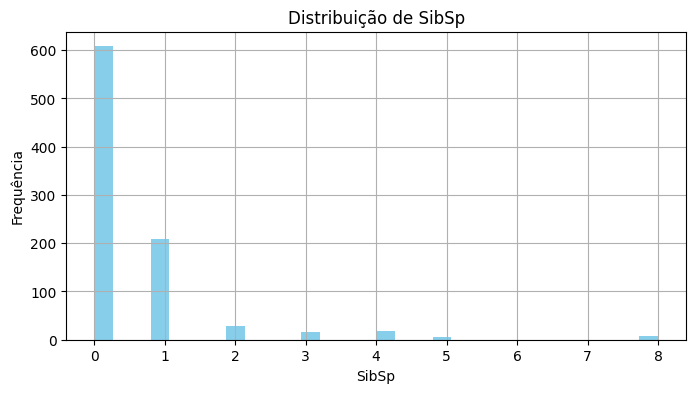

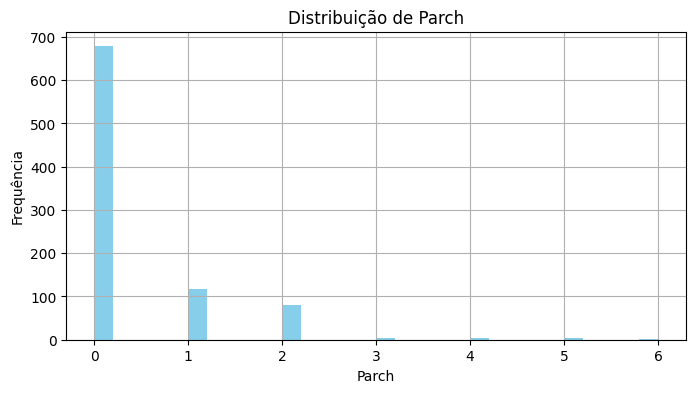

In [ ]:
print("\nDistribuição de variáveis numéricas relevantes (em azul claro):")
for col in ['Age', 'Fare', 'SibSp','Parch']:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=30, color='skyblue') # Changed color to 'skyblue'
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

Esses analise inicial do projeto, serve apenas para ver como as variaveis que serão usadas, estão distribuidas, para termos ciencia de algumas coisas que são importantes antes de seguirmos para a resposta das hipoteses criadas anteriormente. Com base nos gráficos de distribuição acima, podemos observar os seguintes pontos sobre os atributos:

*   **Idade (Age):** A distribuição da idade mostra que a maior parte dos passageiros estavam na faixa dos 20 aos 40 anos, com um pico significativo nos passageiros de 20. Há também uma presença notável de crianças pequenas, a presença de familias no barco.

*   **Tarifa (Fare):** A maioria das passagens teve um custo relativamente baixo, porem, tem um pequeno número de passagens com valores muito altos, o que sugere a presença de passageiros de classes sociais mais elevadas.

*   **Irmãos/Cônjuges (SibSp) e Pais/Filhos (Parch):** Um dado interessante que pode ser tirado desses graficos, é que a maioria esmagadora dos passageiros viajaram sem irmãos/cônjuges ou pais/filhos a bordo (visto no grafico pela contagem de 0). A frequência de passageiros diminui à medida que o número de familiares aumenta, indicando que muitas pessoas viajavam sozinhas ou em grupos de pessoas/familias pequenas.

*   **Classe do Passageiro (Pclass):** A 3ª classe era a mais populosa, com um número significativamente maior de passageiros em comparação com a 1ª e 2ª classes. Isso pode ter implicações na taxa de sobrevivência, dado o maior número de pessoas em uma classe social mais baixa.

*   **Sexo (Sex):** O número de passageiros do sexo masculino era consideravelmente maior do que o número de passageiros do sexo feminino.

*   **Porto de Embarque (Embarked):** Southampton (S) foi o porto de embarque mais comum, seguido por Cherbourg (C) e, por último, Queenstown (Q). A distribuição de classes sociais pode variar entre esses portos.

## 4.1 Resolução de hipoteses
Este bloco ira focar na análise de dados específicos para testar cada uma das hipóteses que foram listadas na seção 1.4 atraves de graficos e analises estatisticas para a verificar se as hipoteses são veridicas, ou se são refutadas.

##Hipotese 1:  Os passageiros de primeira classe sobreviveram mais do que os passageiros de outras classes?


Número de sobreviventes e não sobreviventes por classe:


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119



Taxa de sobrevivência por classe:


,Survival_Rate
Pclass,
1,62.962963
2,47.282609
3,24.236253


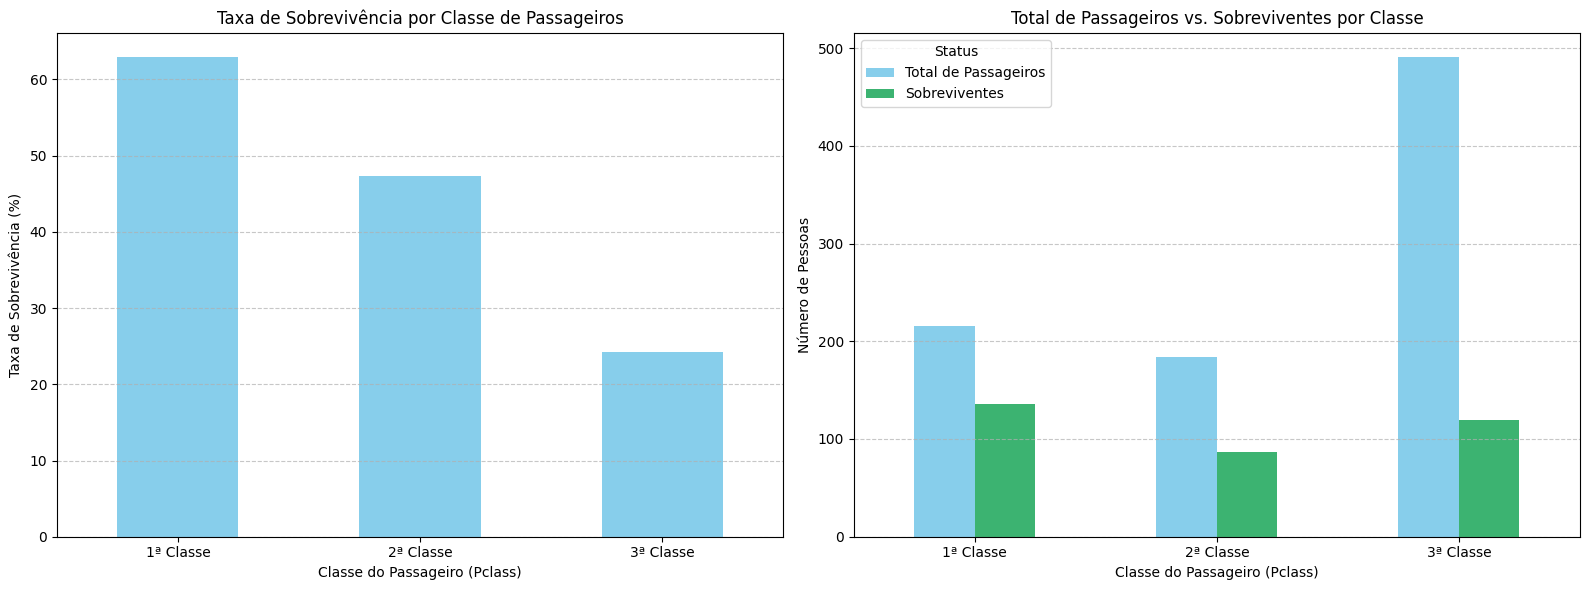

In [ ]:
#Resolução da Hipótese 1

# Agrupando por Pclass e Survived para contar o número de passageiros de cada classe
survival_by_pclass = df.groupby('Pclass')['Survived'].value_counts().unstack().fillna(0)

# Calculo da porcentagem de sobrevivência por classe
survival_by_pclass['Survival_Rate'] = survival_by_pclass[1] / (survival_by_pclass[0] + survival_by_pclass[1]) * 100

print("Número de sobreviventes e não sobreviventes por classe:")
display(survival_by_pclass[[0, 1]])

print("\nTaxa de sobrevivência por classe:")
display(survival_by_pclass['Survival_Rate'].to_frame())

# Criando os gráficos para visualizar a taxa de sobrevivência e a comparação do Total de passageiros de cada classe  x sobreviventes por classe
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Agora apenas dois subplots

# Gráfico 1: Taxa de Sobrevivência por Classe
survival_by_pclass['Survival_Rate'].plot(kind='bar', color='skyblue', ax=axes[0])
axes[0].set_title('Taxa de Sobrevivência por Classe de Passageiros')
axes[0].set_xlabel('Classe do Passageiro (Pclass)')
axes[0].set_ylabel('Taxa de Sobrevivência (%)')
axes[0].set_xticks(ticks=[0, 1, 2], labels=['1ª Classe', '2ª Classe', '3ª Classe'], rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico 2: Comparação total de passageiros x Sobreviventes por Classe
survivors_count = survival_by_pclass[1]
total_passengers_per_class = survival_by_pclass[0] + survival_by_pclass[1]
grouped_data = pd.DataFrame({
    'Total de Passageiros': total_passengers_per_class,
    'Sobreviventes': survivors_count
})
grouped_data.plot(kind='bar', ax=axes[1], color=['skyblue', 'mediumseagreen'])
axes[1].set_title('Total de Passageiros vs. Sobreviventes por Classe')
axes[1].set_xlabel('Classe do Passageiro (Pclass)')
axes[1].set_ylabel('Número de Pessoas')
axes[1].set_xticks(ticks=[0, 1, 2], labels=['1ª Classe', '2ª Classe', '3ª Classe'], rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()


Analisando os graficos de barra acima, é possivel tirar como conclusão que:
1. Os passageiros de primeira classe realmente apresentaram a maior taxa de sobrevivência em comparação com a segunda e a terceira classe, isso significa que
2. O gráfico de número absoluto dos sobreviventes mostra que, embora a terceira classe tivesse mais passageiros total, o número de sobreviventes da terceira classe é significativamente menor em comparação ao dos sobreviventes que estavam na primeira classe, Portanto, os dados apoiam que a hipotese 1 esta correta.

##Hipotese 2: Existe correlação positiva entre o idade do passageiro e a porcentagem de sobrevivencia ?


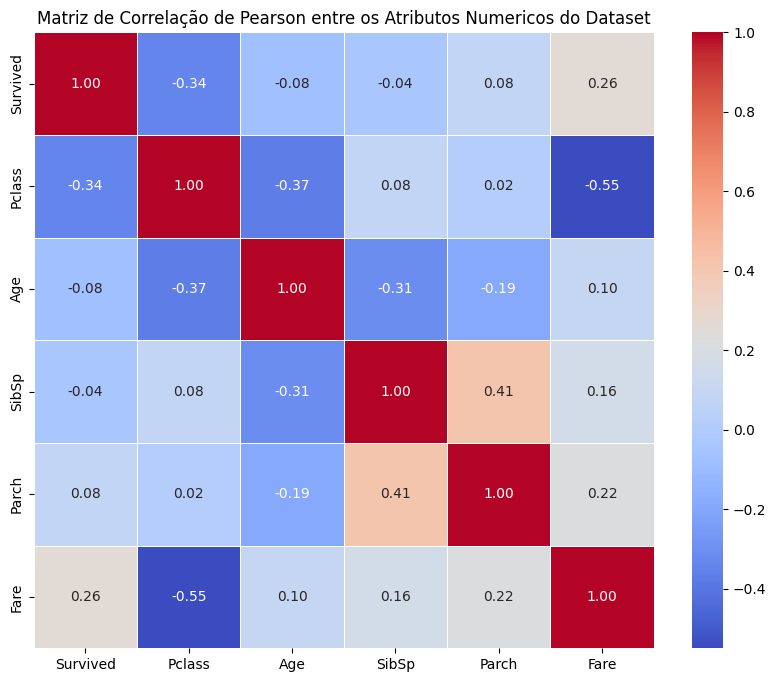

In [ ]:
# Selecionando os atributos numéricos para a matriz de correlação
important_numeric_cols = ['Survived', 'Pclass', 'Age','SibSp', 'Parch', 'Fare']

# Fazendo a matriz de correlação de Pearson
correlation_matrix = df[important_numeric_cols].corr(method='pearson')

# Visualizando a matriz de correlação com um heatmap para melhor entendimento
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação de Pearson entre os Atributos Numericos do Dataset')
plt.show()

Com base na matriz de correlação de Pearson gerada é possivel entender que:
1. O coeficente de correlação entre o atributo **Age** e **Survived** é de **-0.08**, isso indica uma correlação muito fraca, significando que a principio, a hipotese de que a idade poderia possuir  correlação positiva com a sobrevivencia, não esta correta, tornando essa variavel menos relevante no momento de construção do modelo de classificação.
2. Essa matriz de correlação, da insights interessantes sobre a hipotese de numero 6!, Há uma correlação positiva fraca/media (**0.26**) entre **Fare** e **Survived**. Isso indica que passageiros que pagaram tarifas mais altas, possivelmente tem a tendência de sobreviver mais. É consistente e complementa a correlação de **Pclass** com survived, pois tarifas mais altas geralmente estão associadas a classes de passageiros mais elevadas.

##Hipotese 3: A presença de familiares a bordo, medida pelas variáveis de irmãos/cônjuges e pais/filhos, facilitou ou dificultou o processo de sobrevivência dos passageiros?


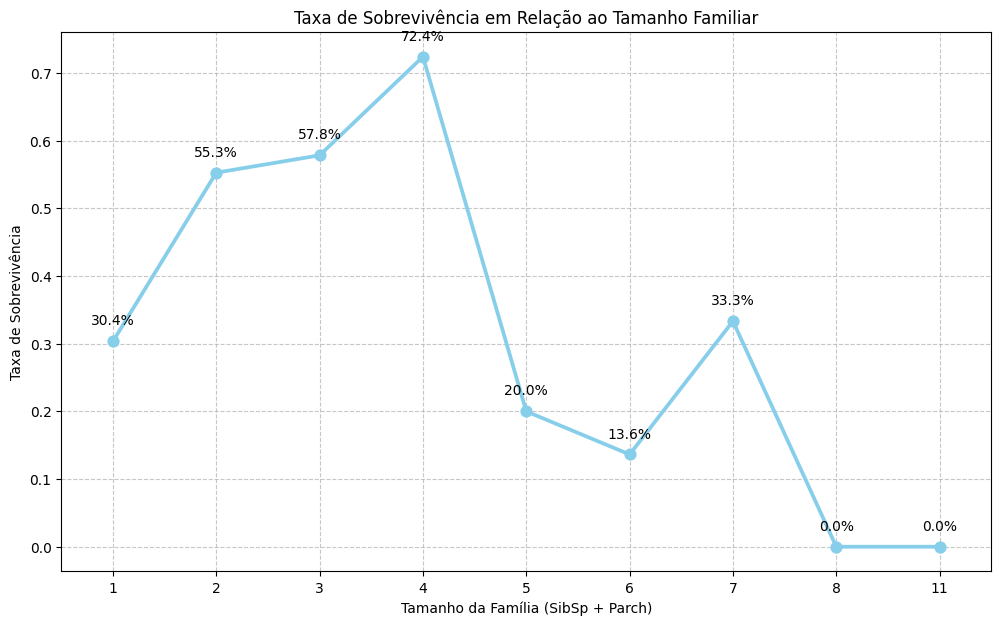

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

survival_by_familysize = df.groupby('FamilySize')['Survived'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.pointplot(x='FamilySize', y='Survived', data=survival_by_familysize, color='skyblue')

# Adicionando os valores percentuais acima de cada ponto do grafico
for index, row in survival_by_familysize.iterrows():
    plt.text(x=index, y=row['Survived'] + 0.02, s=f"{row['Survived']:.1%}", color='black', ha='center', va='bottom')

plt.title('Taxa de Sobrevivência em Relação ao Tamanho Familiar')
plt.xlabel('Tamanho da Família (SibSp + Parch)')
plt.ylabel('Taxa de Sobrevivência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Com base no gráfico de Taxa de Sobrevivência em Relação ao Tamanho Familiar é possível entender que:

1.  Aparentemente, a presença de familiares impactou a sobrevivência de forma não linear. é possivel ver no grafico que Indivíduos que viajaram sozinhos (onde o tamanho da familia é = 1) tiveram uma taxa de sobrevivência de aproximadamente **30.4%**. Esta taxa é inferior à de familias pequenas.
2. Famílias de tamanho pequeno a médio (de 2 a 4 pessoas) apresentaram as maiores taxas de sobrevivência.A taxa de de sobrevivência mais alta foi observado nas famílias de 4 membros **(72.4%)**, seguido por famílias com 3 membros **(57.8%)** e 2 membros **(55.3%)**.
3. Um dado interessante, é que Famílias muito grandes tiveram taxas de sobrevivência significativamente menores, chegando a zero. À medida que o tamanho da família aumenta para 5 ou mais membros, a taxa de sobrevivência diminuiu drasticamente. Famílias com 8 e 11 membros, por exemplo, registraram **0%** de sobrevivência.

O que é possivel resumir desse grafico é que ter alguns familiares a bordo (mas não muitos) pode ter sido benéfico para a sobrevivência, possivelmente devido ao apoio mútuo, enquanto viajar sozinho ou em grupos muito grandes pode ter sido uma desvantagem no cenário de emergência, isso significa então que a hipotese nº3 esta parcialmente correta, a presença de familiares pode ajudar ou prejudicar, e isso aparenta depender de quantas pessoas da familia estão a bordo.

##Hipotese 4. O porto onde o passageiro embarcou (Cherbourg, Queenstown ou Southampton) influenciou indiretamente na sobrevivência, possivelmente devido à distribuição de classes sociais predominantes em cada local de partida?

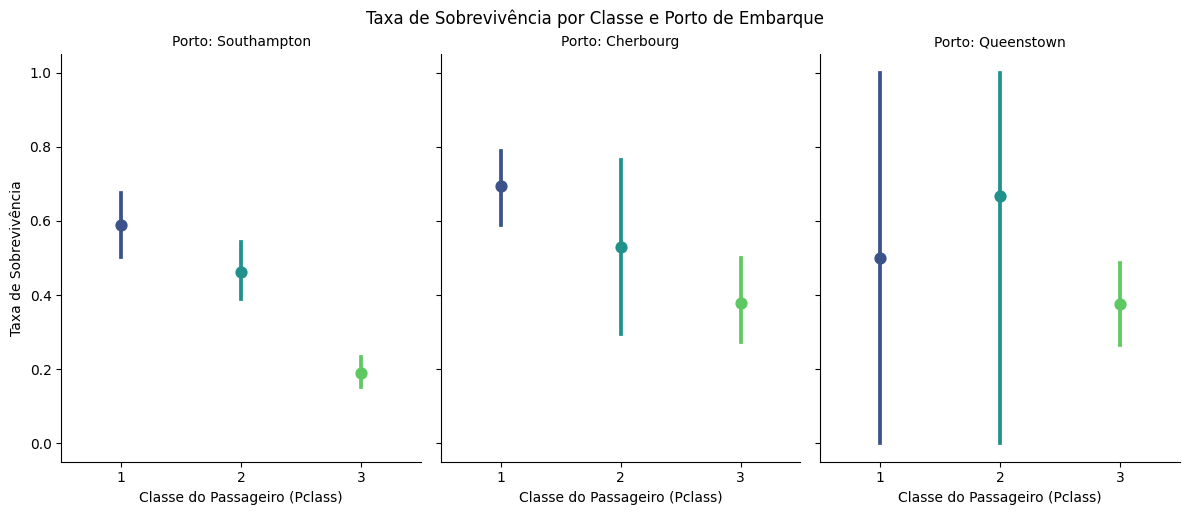

In [ ]:
# Imputando valores ausentes em 'Embarked' com a moda
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)

# #Tranformando as letras dos portos em nomes completos
embark_mapping = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
df_mapped_embarked = df.copy()
df_mapped_embarked['Embarked'] = df_mapped_embarked['Embarked'].map(embark_mapping)

# Criação do catplot para visualizar a taxa de sobrevivência por porto de embarque e classe
g = sns.catplot(
    data=df_mapped_embarked,
    x='Pclass',
    y='Survived',
    col='Embarked',
    kind='point',
    height=5, aspect=0.8, palette='viridis'
)

g.set_axis_labels("Classe do Passageiro (Pclass)", "Taxa de Sobrevivência")
g.set_titles("Porto: {col_name}")
plt.suptitle('Taxa de Sobrevivência por Classe e Porto de Embarque', y=1.02)
plt.show()

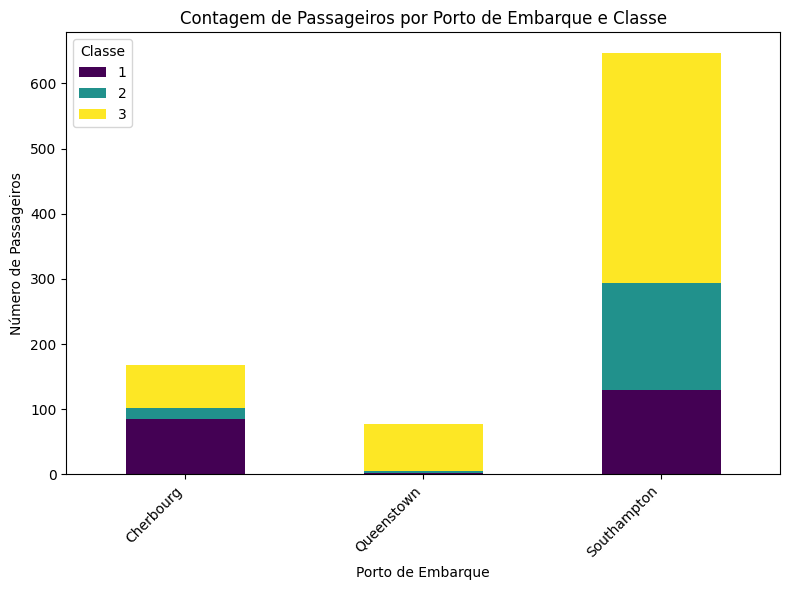

In [ ]:
plt.figure(figsize=(8, 6))

#Tranformando as letras dos portos em nomes completos
embark_mapping = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
df_mapped_embarked = df.copy()
df_mapped_embarked['Embarked'] = df_mapped_embarked['Embarked'].map(embark_mapping)

embark_pclass_counts = df_mapped_embarked.groupby(['Embarked', 'Pclass']).size().unstack(fill_value=0)
embark_pclass_counts.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
plt.title('Contagem de Passageiros por Porto de Embarque e Classe')
plt.xlabel('Porto de Embarque')
plt.ylabel('Número de Passageiros')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Classe')
plt.tight_layout()
plt.show()

Foram usados dois graficos para responder a hipotese, um grafico de barras e um catplot, as descobertas feitas com esses graficos são:

1.  A Hipótese 4 está correta: A distribuição de classes sociais predominantes em cada porto de embarque influenciou indiretamente a taxa de sobrevivência. O `catplot` mostra claramente que, independentemente do porto, a 1ª Classe, teve as maiores taxas de sobrevivência, seguida pela 2ª Classe e por fim, pela 3ª Classe .
2.  Cherbourg (C): O gráfico de barras revela que Cherbourg teve uma proporção significativa de passageiros da 1ª Classe. Consequentemente, o `catplot` para Cherbourg mostra uma alta taxa de sobrevivência para a 1ª Classe, contribuindo para uma percepção de maior chance de sobrevivência geral para passageiros desse porto.
3.  Queenstown (Q): Este porto se destaca por ter uma esmagadora maioria de passageiros da 3ª Classe, com pouquíssimos de 1ª e 2ª Classes. Como a 3ª Classe teve consistentemente as menores taxas de sobrevivência em todos os portos, a predominância dessa classe em Queenstown implica que a taxa de sobrevivência geral para quem embarcou ali seria consequentemente menor.
4.  Southampton (S):Foi o porto com o maior volume de passageiros, e embora tivesse passageiros de todas as classes, a 3ª Classe era a mais numerosa. O `catplot` confirma que passageiros da 3ª Classe de Southampton tiveram uma baixa taxa de sobrevivência. A grande quantidade de passageiros dessa classe neste porto, impactaria negativamente a taxa de sobrevivência média de Southampton, mesmo com a presença de passageiros de classes mais altas com boas taxas de sobrevivência.

Em resumo, os gráficos demonstram que o porto de embarque não influenciou diretamente a sobrevivência por si só, mas sim pela composição socioeconômica dos passageiros que embarcavam em cada local. Portos com maior concentração de passageiros de classes mais altas (e consequentemente maiores taxas de sobrevivência) apresentariam, em média, melhores resultados de sobrevivência, e vice-versa, confirmando a validade da hipótese que o porto de embarque, influenciou sim a taxa de sobrevivencia, mesmo que de forma indireta.

##Hipotese 5:  A porcentagem de sobrevivencia das mulheres foi maior do que a dos homens ?

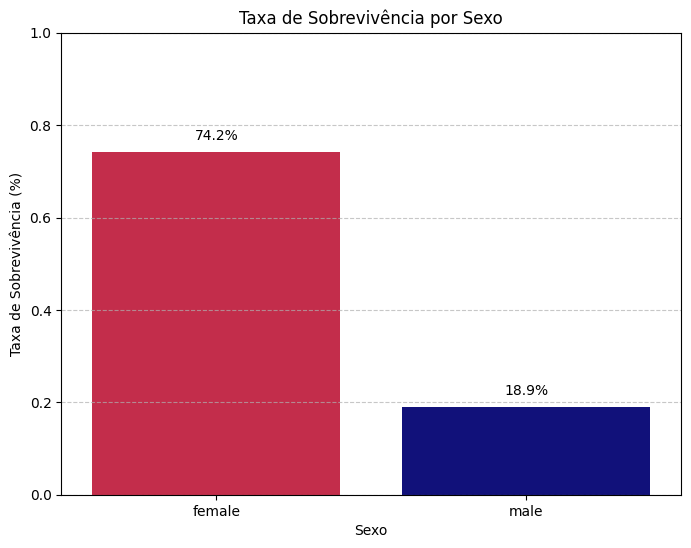

In [ ]:
survival_by_sex = df.groupby('Sex')['Survived'].mean().reset_index()

plt.figure(figsize=(8, 6))

custom_palette = {'female': 'crimson', 'male': 'darkblue'}
sns.barplot(x='Sex', y='Survived', data=survival_by_sex, palette=custom_palette)

# Adicionando os valores percentuais acima de cada barra
for index, row in survival_by_sex.iterrows():
    plt.text(row.name, row['Survived'] + 0.02, f"{row['Survived']:.1%}", color='black', ha='center', va='bottom')

plt.title('Taxa de Sobrevivência por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.ylim(0, 1) # Define o limite y de 0 a 1 para representar a porcentagem
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Com base no gráfico de barras gerado, é possível entender que:
1. A porcentagem de sobrevivência das mulheres foi significativamente maior do que a dos homens. As mulheres apresentaram uma taxa de sobrevivência de aproximadamente **74.2%**, enquanto os homens tiveram uma taxa de sobrevivência de cerca de **18.9%**.
2. Esta grande diferença nas taxas de sobrevivência entre os sexos confirma a Hipótese 5, de que a porcentagem de sobrevivência das mulheres foi maior do que a dos homens. Este dado é crucial para entender os padrões de sobrevivência no naufrágio do Titanic e sugere que o sexo foi um fator determinante nas chances de resgate, validando a hipotese que essa variavel é importante para o modelo de classificação.

##Hipotese 6. a tarifa(fare) paga pelo passageiro, influenciou diretamente na sobrevivencia?

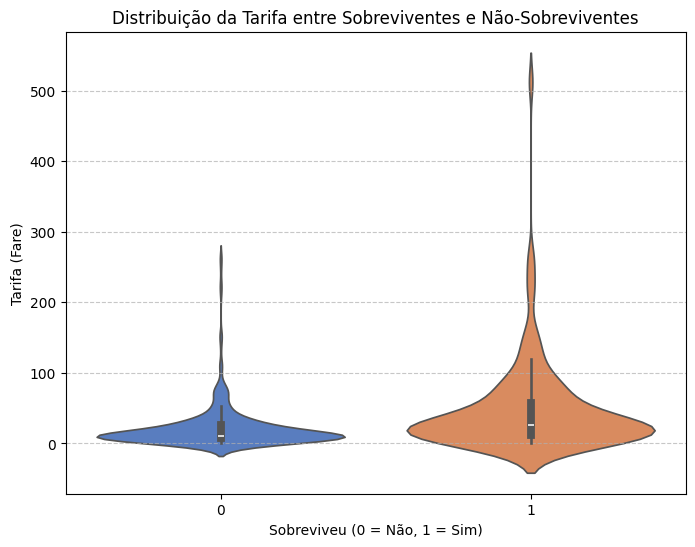

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Survived', y='Fare', data=df, palette='muted')
plt.title('Distribuição da Tarifa entre Sobreviventes e Não-Sobreviventes')
plt.xlabel('Sobreviveu (0 = Não, 1 = Sim)')
plt.ylabel('Tarifa (Fare)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

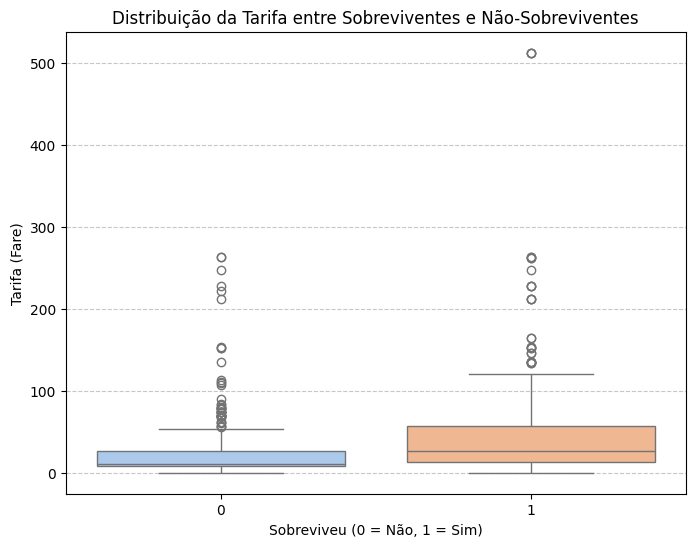

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Fare', data=df, palette='pastel')
plt.title('Distribuição da Tarifa entre Sobreviventes e Não-Sobreviventes')
plt.xlabel('Sobreviveu (0 = Não, 1 = Sim)')
plt.ylabel('Tarifa (Fare)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

O boxplot foi usado para comparar a tarifa mediana paga por passageiros que sobreviveram e que nao sobreviveram, a partir desse grafico, é possivel entender que?
1.  A distribuição das tarifas é visivelmente diferente entre os dois grupos(sobreviventes e não-sobreviventes). A mediana da tarifa paga pelos passageiros que sobreviveram é um tanto quanto mais alta do que a dos passageiros que não sobreviveram. Isso indica que, em média, aqueles que pagaram mais pela passagem tiveram uma maior chance de sobrevivência.
2.  Esta observação aprova a Hipótese 6, que a tarifa paga pelo passageiro influenciou diretamente na sobrevivência. Além disso, está em linha com a correlação positiva fraca/média de 0.26 observada anteriormente entre 'Fare' e 'Survived' na matriz de correlação, e também é consistente com a Hipótese 1, que mostrou uma maior taxa de sobrevivência para passageiros de classes mais altas (que geralmente pagavam tarifas mais caras). Portanto, a tarifa é um fator importante a ser considerado no modelo de classificação.

##4.2 Sintese da Analise Exploratoria

Com base na análise exploratória realizada, é possível sintetizar as seguintes descobertas cruciais para entender os padrões de sobrevivência e identificar variáveis importantes para o modelo de classificação:

### Descobertas Gerais da EDA Inicial:
*   **Distribuição de Idade (Age):** A maioria dos passageiros tinha entre 20 e 40 anos, com uma presença notável de crianças pequenas.
*   **Distribuição de Tarifa (Fare):** Predominância de passagens de baixo custo, mas com um segmento de tarifas muito altas, indicando a presença de diferentes classes sociais.
*   **Tamanho da Família (SibSp e Parch):** A maioria dos passageiros viajou sozinha ou em grupos familiares muito pequenos.
*   **Classe do Passageiro (Pclass):** A 3ª classe era a mais populosa.
*   **Sexo (Sex):** Mais passageiros do sexo masculino do que feminino.
*   **Porto de Embarque (Embarked):** Southampton foi o porto mais comum, seguido por Cherbourg e Queenstown, cada um com uma composição social distinta de passageiros.

### Descobertas das Hipóteses:

1.  **Hipótese 1 (Pclass):** Confirmada. Passageiros da 1ª classe tiveram a maior taxa de sobrevivência **(aproximadamente 63%)**, enquanto a 3ª classe teve a menor **(cerca de 24%)**. Isso valida 'Pclass' como um preditor forte.

2.  **Hipótese 2 (Age):** Refutada. A correlação entre 'Age' e 'Survived' foi muito fraca (-0.08), indicando que a idade, por si só, não teve uma influência direta significativa na sobrevivência. No entanto, a distribuição etária talvez possa ser relevante em combinação com outros fatores.

3.  **Hipótese 3 (Tamanho da Família - SibSp e Parch):** Parcialmente Confirmada. A presença de familiares impactou a sobrevivência de forma não linear. Famílias pequenas a médias apresentaram as maiores taxas de sobrevivência chegando a **72.4%** para famílias de 4 pessoas, enquanto indivíduos que viajaram sozinhos tiveram **30.4%** e famílias muito grandes tiveram **0%** para 8 e 11 membros. Isso sugere que a interação social e o apoio podem ter sido benéficos até certo ponto.

4.  **Hipótese 4 (Embarked):** Confirmada. O porto de embarque influenciou indiretamente a sobrevivência devido à sua composição de classes sociais. Por exemplo, Cherbourg, com uma alta proporção de passageiros da 1ª classe, teve taxas de sobrevivência geralmente mais altas, enquanto Queenstown, predominantemente da 3ª classe, teve taxas menores. 'Embarked' é importante como um proxy para a classe social e, consequentemente, para as chances de sobrevivência.

5.  **Hipótese 5 (Sex):** Confirmada. A porcentagem de sobrevivência das mulheres foi significativamente maior **(74.2%)** do que a dos homens **(18.9%)**. Esta é uma das variáveis mais determinantes para a sobrevivência, refletindo a política de 'mulheres e crianças primeiro'.

6.  **Hipótese 6 (Fare):** Confirmada. A tarifa paga ('Fare') demonstrou ter uma correlação positiva com a sobrevivência. A mediana da tarifa para sobreviventes é visivelmente mais alta do que para não-sobreviventes, sugerindo que passageiros que pagaram mais (e que geralmente eram de classes superiores) tiveram maior chance de sobreviver. Esta variável é um forte preditor e está alinhada com a influência da classe dos passageiros.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, as colunas que serão ultilizadas para o modelo de classificação de sobrevivencia, ja foram decididos anteriormente.
De acordo com a analise exploratoria feita nos blocos acima, serão ultilizadas as seguintes variaveis:

1. **`Pclass` (Classe do Passageiro):** Selecionada devido à forte correlação com a sobrevivência, uma das variaveis mais importantes para o projeto, conforme demonstrado na **Hipótese 1**. Passageiros de classes mais altas apresentaram taxas de sobrevivência significativamente maiores.

2. **`Sex` (Gênero):** Tambem uma variavel essencial para o modelo, pois a **Hipótese 5** foi claramente confirmada, mostrando que a taxa de sobrevivência das mulheres foi drasticamente maior que a dos homens.

3. **`SibSp` (Número de Irmãos/Cônjuges a bordo) e `Parch` (Número de Pais/Filhos a bordo):** Combinadas para formar a variável `FamilySize` (tamanho da família), que demonstrou um impacto não linear na sobrevivência, conforme a **Hipótese 3**, que foi parcialmente confirmada. Famílias de tamanho pequeno a médio tiveram as maiores taxas de sobrevivência, enquanto indivíduos sozinhos ou com famílias muito grandes tiveram taxas menores. Essas variáveis, ou a derivada `FamilySize`, são importantes para capturar o impacto do apoio familiar em uma situação de crise.

4. **`Embarked` (Porto de Embarque):** A **Hipótese 4** confirmou que o porto de embarque influenciou indiretamente na sobrevivência dos passageiros, atuando como um proxy para a composição socioeconômica dos passageiros. Diferentes portos tinham diferentes tamanhos de passageiros por classe, o que se correlacionava com as chances de sobrevivência.

5. **`Fare` (Tarifa):** A **Hipótese 6** confirmou uma correlação positiva entre a tarifa paga e a sobrevivência. Passageiros que pagaram tarifas mais altas (geralmente pessoas de classes superiores) tiveram maior probabilidade de sobreviver. Esta variável complementa as informações da variavel`Pclass`.

6. **'Survived'(Sobreviveu):** É a variavel target to projeto, queremos prever se uma pessoa sobreviveria ou não ao naufragio do titanic.

**Variáveis Removidas:**
*   **`PassengerId`:** É um identificador único sem muito valor preditivo.
*   **`Name` e `Ticket`:** Contêm informações de texto e pouca relevância preditiva direta para o problema de classificação geral.
*   **`Cabin`:** Possui uma grande quantidade de valores ausentes (aproximadamente 77%), o que a torna inviável para uso direto e o tratamento seria muito  sujeito a incerteza, possivelmente afetando o modelo. Embora a existência de cabine pudesse ser relevante, a quantidade de dados faltantes infelizmente compromete seu uso.

claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

Abaixo, está o bloco de separação do modelo em treino e teste:


In [ ]:
# === Configuração do problema ===
TARGET = "Survived"                  # O atributo target para classificação
PROBLEM_TYPE = "classificacao"    # Tipo de problema: classificação
ID_COLUMNS = ["PassengerId"]                    # Coluna de ID
DATE_COLUMN = None                 # Não possui coluna de data
DROP_COLUMNS = ["Name", "Ticket", "Cabin"]  # Colunas removidas(não tem valor de predição)

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: Survived
Número de features: 8
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize']


In [ ]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.3, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (623, 8) | Teste: (268, 8)


## 5.1 Justificativa da divisão

> A divisão `train_test_split` com `test_size=0.3` e `random_state=SEED` foi escolhida para este problema de classificação por várias razões:

> 1.  **Tipo de Problema:** O problema é de **classificação**, e a análise exploratória revelou que a variável `TARGET` ("Survived") possui uma distribuição moderadamente desbalanceada (aproximadamente 61.62% não sobreviveram e 38% sobreviveram).

> 2.  **Estratificação:** Para garantir que a proporção das classes do `TARGET` seja mantida tanto no conjunto de treino quanto no de teste, foi utilizado no codigo o `stratify=y`. Foi feito para evitar que um dos conjuntos tenha uma representação desproporcional da classes minoritárias, o que poderia levar a um modelo enviesado.

> 3.  **Proporção Treino/Teste:** O dataset possui 891 observações. Uma divisão de 70% para treino e 30% para teste, pareceu adequada para o tamanho do dataset, fornecendo uma quantidade razoável de dados para o modelo aprender padrões e tambem reservan um conjunto de teste significativo para uma boa avaliação.


> 4.  **Prevenção de Vazamento de Dados:** Ao separar os dados em treino e teste antes de qualquer etapa de pré-processamento dos dados, já garante que o conjunto de teste permaneça intacto.

# 6. Pré-processamento e pipeline

A partir desse bloco, sera feito algumas etapas essenciais de pre-processamento antes dos dados serem usados para treinamento do modelo algumas dessas etapas são:
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- engenharia de atributos;
-tratamento de outliers;

In [ ]:
class IQR_Capper(BaseEstimator, TransformerMixin):
    """Transformer para capping de outliers usando o método IQR."""
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bound = None
        self.upper_bound = None

    def fit(self, X, y=None):
        # Calcula o Q1 (25º percentil) e Q3 (75º percentil) para cada coluna.
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1

        # Calcula os limites inferior e superior para capping
        self.lower_bound = Q1 - (IQR * self.factor)
        self.upper_bound = Q3 + (IQR * self.factor)
        return self

    def transform(self, X):
        X_transformed = X.copy()
        X_transformed = np.where(X_transformed < self.lower_bound, self.lower_bound, X_transformed)
        X_transformed = np.where(X_transformed > self.upper_bound, self.upper_bound, X_transformed)

        return X_transformed

In [ ]:
# --- Identificação automática simples de colunas numéricas e categóricas. ---
# Revise manualmente, especialmente se houver datas, IDs, texto livre ou categorias codificadas como números.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

# --- Atualização do pipeline numérico com o tratamento de outliers ---
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("outlier_capper", IQR_Capper(factor=1.5)), # Novo passo para tratamento de outliers
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
Colunas categóricas: ['Sex', 'Embarked']


## 6.1 Decisões de pré-processamento  
> As decisões de pré-processamento foram tomadas procurando uma robustez maior do modelo e a prevenção de data leakage, garantindo que as transformações fossem ajustadas apenas no conjunto de treino e aplicadas no conjunto de teste. O pipeline passa pelas seguintes etapas:

> ### Tratamento para Colunas Numéricas (`numeric_pipe`):
> 1.  **Tratamento de Valores Ausentes:** A mediana foi escolhida para imputar valores ausentes na coluna 'Age' e em outras variaveis numéricas, por ser menos sensível a outliers do que a média. Visto que a distribuição de 'Age' e 'Fare' não são perfeitamente simétricas, a mediana oferece uma representação mais robusta do valor central, evitando distorções que a média poderia introduzir.
> 2.  **Tratamento de Outliers (`IQR_Capper(factor=1.5)`):** Um capper baseado no Intervalo Interquartil (IQR) foi introduzido para limitar outliers nas colunas numéricas. Outliers podem ter um impacto significativo em modelos sensíveis à escala e distribuição dos dados. Ao limitar esses valores extremos, busca-se reduzir sua influência indevida no treinamento do modelo.
> 3.  **Padronização (`StandardScaler()`):** A padronização dos dados (`StandardScaler`) é crucial para algoritmos que são sensíveis à escala das variáveis. Ela transforma as variáveis para que tenham média zero e desvio padrão um, garantindo que nenhuma feature domine o cálculo de distâncias ou gradientes simplesmente por ter uma escala maior, isso evita algumas variaveis terem o peso maior que outras.

> ### Tratamento para Colunas Categóricas (`categorical_pipe`):
> 1.  **Imputação de Valores Ausentes** Para as colunas categóricas ('Sex', 'Embarked'), a estratégia de imputação pela moda foi utilizada. No caso de 'Embarked', que possuía poucos valores ausentes, preenchê-los com a categoria mais frequente é uma abordagem simples e eficaz que minimiza a introdução de ruído.
> 2.  **One-Hot Encoding (`OneHotEncoder(handle_unknown="ignore")`):** As variáveis categóricas foram transformadas usando One-Hot Encoding. É uma prática segura para lidar com categorias que possam aparecer no conjunto de teste, mas não estiveram presentes no conjunto de treino, prevenindo erros durante a transformação.

> ### Variáveis Removidas:
> -   **`PassengerId`**: Removida por ser apenas um identificador único, sem valor preditivo para o modelo.
> -   **`Name` e `Ticket`**: Removidas por serem variáveis textuais com alta cardinalidade e pouca relevância preditiva direta para o problema de classificação binária.
> -   **`Cabin`**: Removida devido ao grande número de valores ausentes (aproximadamente 77%). Imputar tantos valores seria arriscado e poderia introduzir viés significativo ou ruído no modelo.

> ### Nova Variável Criada:
> -   **`FamilySize`**: Criada como a soma de `SibSp` (irmãos/cônjuges) + `Parch` (pais/filhos) + 1 (para incluir o próprio passageiro). Esta variável foi crucial para testar a Hipótese 3, que demonstrou que o tamanho da família tem uma relação não linear com a sobrevivência. Essa nova feature está disponível no momento da previsão, pois pode ser calculada a partir dos dados de entrada.

# 7. Baseline e modelos candidatos
Nesta seção, definiremos um modelo baseline para estabelecer uma referência de desempenho e selecionaremos modelos candidatos para comparação. O baseline serve como um ponto de partida para avaliar se nossos modelos mais complexos realmente agregam valor significativo. Os modelos candidatos serão escolhidos com base na adequação ao tipo de problema (classificação) e à natureza dos dados.


In [ ]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ]),
        "SVC": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", SVC(random_state=SEED, probability=True)) # probability=True para roc_auc
        ]),
        "XGBoost": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", XGBClassifier(random_state=SEED, eval_metric='logloss')) # 'logloss' é comum para classificação binária
        ]),
        "KNeighbors": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KNeighborsClassifier())
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['LogisticRegression', 'RandomForest', 'SVC', 'XGBoost', 'KNeighbors']


## 7.1 Justificativa dos modelos

### **Baseline DummyClassifier**
*   **Coerência:** O `DummyClassifier` com estratégia `most_frequent` é uma baseline fundamental e coerente. Ele serve como o ponto de referência mínimo, prevendo sempre a classe majoritária (nesse caso, "não sobreviveu"). Qualquer modelo mais complexo deve, obrigatoriamente, superar o desempenho desta baseline para ser considerado útil..

### **Modelos Candidatos**

1.  **LogisticRegression (Regressão Logística)**
    *   **Adequação:** A Regressão Logística é um modelo linear amplamente utilizado para classificação binária, conhecido por sua simplicidade e interpretabilidade. É um bom modelo para iniciar, pois pode identificar relações lineares nos dados de forma eficiente e serve como uma forte baseline para a capacidade preditiva linear.
    *   **Tratamento:** Por ser um modelo linear baseado em otimização numérica, beneficia-se grandemente da escala das features, o que é garantido pelo `StandardScaler` em nosso pipeline de pré-processamento. `max_iter=500` é configurado para garantir a convergência do algoritmo.

2.  **RandomForestClassifier (Random Forest)**
    *   **Adequação:** O Random Forest é um algoritmo de ensemble baseado em árvores de decisão. É robusto, menos propenso a overfitting do que árvores individuais, e capaz de capturar relações não-lineares e interações complexas entre as features.
    *   **Restrições:** É menos interpretável que a Regressão Logística, mas permite a extração de importância das features.

3.  **SVC (Support Vector Classifier)**
    *   **Adequação:** O SVC é um modelo poderoso que pode realizar classificação linear e não-linear, é interessante compara-lo com os outros modelos.
    *   **Tratamento:** É **altamente sensível à escala das features**. A padronização feita pelo `StandardScaler` no `preprocess` pipeline é crucial para o bom desempenho do SVC.

4.  **XGBoost (XGBClassifier)**
    *   **Adequação:** XGBoost é uma implementação altamente otimizada de gradient boosting, ele constrói árvores de decisão sequencialmente, onde cada nova árvore corrige os erros das árvores anteriores, resultando em um modelo muito forte.
    *   **Tratamento:** Embora possa lidar com valores ausentes internamente, ele se beneficia da padronização e da preparação de features realizada pelo `preprocess` pipeline.
    *   **Restrições:** Oferece excelente desempenho e é eficiente. A interpretabilidade é menor em comparação com modelos mais simples, mas pode fornecer importância das features.

5.  **KNeighborsClassifier (KNN)**
    *   **Adequação:** KNN é um algoritmo simples e baseado em instâncias. É bom em datasets menores e quando a fronteira de decisão é irregular.
    *   **Tratamento:** É **extremamente sensível à escala das features**, pois a classificação é baseada na distância. O `StandardScaler` no pipeline `preprocess` é, portanto, indispensável para garantir que todas as features contribuam igualmente para o cálculo da distância.
    *   **Restrições:** Possui baixa interpretabilidade. A fase de treinamento é rápida, mas a fase de predição pode ser lenta em datasets muito grandes, pois exige o cálculo de distâncias para cada nova previsão. Para o dataset do Titanic, isso não é um problema.

##8. Treinamento e avaliação inicial
Esse bloco é referente ao treinamento dos modelos candidatos para comparação inicial.



In [ ]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


,baseline,LogisticRegression,RandomForest,SVC,XGBoost,KNeighbors
accuracy,0.615672,0.787313,0.794776,0.802239,0.764925,0.753731
f1_weighted,0.469219,0.786700,0.792812,0.798772,0.762087,0.751071
roc_auc,0.500000,0.846102,0.832627,0.838217,0.818241,0.812151
train_time_s,0.023000,0.079000,0.573000,0.179000,0.640000,0.114000



### 8.1 Análise dos resultados iniciais
Realizando a analise dos resultados do bloco acima, é possivel responder algumas perguntas sobre o resultado do treinamento dos modelos.

> **O modelo superou o baseline?**
> Sim, todos os modelos candidatos superaram significativamente o baseline (`DummyClassifier`) em todas as métricas avaliadas. O `DummyClassifier` obteve um `f1_weighted` de 0.469 e `roc_auc` de 0.500, o que é esperado para um modelo que prevê a classe majoritária. Os modelos candidatos atingiram `f1_weighted` entre 0.751 e 0.799 e `roc_auc` entre 0.812 e 0.846.

> **A métrica escolhida é suficiente para avaliar o problema?**
> Sim, a combinação das métricas `accuracy`, `f1_weighted` e `roc_auc` é bastante adequada para este problema de classificação binária. O `f1_weighted` é importante por considerar precisão e recall, dando uma boa ideia das classes desbalanceadas. O `roc_auc` é robusto ao desbalanceamento e indica a capacidade de discriminação do modelo entre as classes.

> **Algum modelo parece sofrer de underfitting?**
> O modelo `baseline` aparenta sofrer de underfitting , pois não aprendeu nenhum padrão nos dados. No entanto, os modelos candidatos apresentaram desempenho bem superior, indicando que aprenderam relações nos dados..

> **O tempo de treinamento é aceitável?**
> Sim, o tempo de treinamento para todos os modelos, incluindo a baseline e os candidatos, foi extremamente baixo. Isso é perfeitamente aceitável para o tamanho do dataset e para o contexto de um MVP, permitindo iterações rápidas.

> **O resultado faz sentido considerando a EDA?**
> Sim, os resultados fazem sentido em relação à Análise Exploratória de Dados (EDA). A EDA revelou fortes relações entre variáveis como `Sex`, `Pclass` e `Fare` com a sobrevivência, bem como a relação não linear de `FamilySize`. Modelos mais complexos como `SVC` e `RandomForest` capturaram essas complexidades, resultando em desempenho superior.

# 9. Validação e otimização de hiperparâmetros

Esse bloco é exclusivo para a otimização de hiperparametros e para demonstrar/clarear o que foi realizado nessa etapa a partir de perguntas realizadas como base:

### Otimização de Hiperparâmetros
-   **Qual modelo foi otimizado?**
    O modelo otimizado foi o RandomForestClassifier.

-   **Quais hiperparâmetros foram testados?**
    Os hiperparâmetros testados foram:
    *   `model__n_estimators`:As árvores na floresta, testadas foram de 50 a 250.
    *   `model__max_depth`: É a Profundidade máxima da árvore, de 2 a 20.
    *   `model__min_samples_split`: O número mínimo de amostras necessárias para dividir um nó interno, testado no intervalo de 2 a 10.

-   **Qual estratégia de validação foi usada?**
    Foi utilizada uma validação cruzada estratificada com 5 splits, garantindo que a proporção das classes do target fosse mantida em cada fold.

-   **Qual métrica guiou a escolha?**
    A métrica que guiou a escolha foi o `f1_weighted`.

-   **Qual foi a melhor configuração?**
    A melhor configuração de hiperparâmetros encontrada foi:
    *   `model__max_depth`: 5
    *   `model__min_samples_split`: 9
    *   `model__n_estimators`: 201
""")


In [ ]:
# === Otimização de hiperparâmetros ===

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # usando 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.8251146226353882
Melhores hiperparâmetros: {'model__max_depth': 5, 'model__min_samples_split': 9, 'model__n_estimators': 201}


## 9.1 Discussão da otimização

De acordo com os resultados da analise inicial, talvez seja necessario uma discussão sobre a otimização do modelo respondendo a algumas perguntas como:
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

1. A otimização dos hiperparâmetros do `RandomForestClassifier` resultou em uma melhoria no score de validação. O modelo `RandomForest` inicial obteve um `f1_weighted` de 0.7928, enquanto o melhor modelo encontrado na busca aleatória (`RandomizedSearchCV`) atingiu um `f1_weighted` de 0.8251.

2. A busca foi intencionalmente limitada por custo computacional e tempo.Foi configurado `N_ITER_SEARCH = 5` para o `RandomizedSearchCV`, o que significa que apenas 5 combinações de hiperparâmetros foram testadas aleatoriamente.

3. Os hiperparâmetros escolhidos fazem bastante sentido. Uma profundidade máxima (`max_depth`) relativamente baixa (5) ajuda a evitar overfitting, mantendo o modelo mais generalizável. Um `min_samples_split` de 9 é um valor razoável para a divisão dos nós, e 201 estimadores (`n_estimators`) é um número robusto para um `RandomForest`, fornecendo um bom equilíbrio entre desempenho e complexidade. Eles sugerem um modelo robusto e não excessivamente complexo.



# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: modelo_otimizado
              precision    recall  f1-score   support

           0       0.80      0.92      0.85       165
           1       0.82      0.63      0.71       103

    accuracy                           0.81       268
   macro avg       0.81      0.77      0.78       268
weighted avg       0.81      0.81      0.80       268



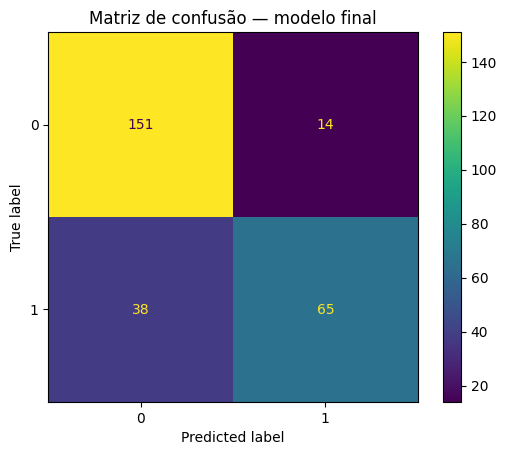

In [ ]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


  ## 10.1 Análise de erros e limitações

Realizando uma analise de erros e das limitações do modelo, é possivel ver um resultado muito interessante do modelo de random forest, tanto em erros quanto em acertos sendo esses o seguinte:

> *   **Verdadeiros Negativos (TN):** 151 passageiros foram corretamente previstos como não sobreviventes.
> *   **Falsos Positivos (FP):** 14 passageiros foram incorretamente previstos como sobreviventes.
> *   **Falsos Negativos (FN):** 38 passageiros foram incorretamente previstos como não sobreviventes, mas de fato sobreviveram.
> *   **Verdadeiros Positivos (TP):**65 passageiros foram corretamente previstos como sobreviventes.
>
> O modelo comete mais erros do tipo Falso Negativo do que Falso Positivo. Isso significa que ele tem uma maior tendência a prever que alguém não sobreviverá, mesmo que a pessoa tenha sobrevivido. Para o contexto do problema, errar em prever que alguém não sobreviverá,quando na verdade sobreviveu,pode ser menos crítico do que errar em prever que alguém sobreviverá quando na verdade não o fez, dependendo da perspectiva.
>
> ### Sinais de Overfitting ou Underfitting
> *   **Underfitting:** O modelo otimizado superou significativamente o baseline com um `f1_weighted` de 0.80 no conjunto de teste, comparado a 0.469 do baseline. Isso indica que o modelo aprendeu padrões nos dados e não está sofrendo de underfitting severo.
> *   **Overfitting:** O score `f1_weighted` na validação cruzada durante a otimização foi de 0.8251, enquanto no conjunto de teste final foi de 0.80. Essa pequena diferença sugere que o modelo generaliza razoavelmente bem e não apresenta sinais de overfitting significativo.
>
> ### Adequação das Métricas Escolhidas
> A combinação de `accuracy`, `f1_weighted` e `roc_auc` é adequada para o problema de classificação binária. O `f1_weighted` é particularmente útil por considerar a precisão e o recall e por lidar melhor com o desbalanceamento das classes.
>
> ### Viés, Limitação de Dados e Risco de Generalização
> *   **Viés:** Há um viés aparente na previsão do modelo, com maior recall para a classe '0' e menor recall para a classe '1'. Isso pode ser resultado do leve desbalanceamento da classe alvo, levando o modelo a ser mais conservador na previsão de sobrevivência.
> *   **Limitação de Dados:** O dataset do Titanic é relativamente pequeno (891 observações), o que pode limitar a capacidade do modelo de aprender padrões mais complexos e finos, além de aumentar o risco de que os padrões identificados sejam muito específicos para este conjunto de dados.
> *   **Risco de Generalização:** O modelo foi treinado em dados históricos de um evento único. As relações e padrões identificados podem ser específicos ao contexto da época e às condições do naufrágio do Titanic.
>
> ### Cenários de Uso Inapropriados para o Modelo
> Este modelo **não deveria ser usado** para:
> 1.  **Operações de Resgate em Tempo Real:** As previsões desse modelo não são apropriadas para auxiliar decisões de vida ou morte em um desastre real e moderno. Principalmente porque é feito um projeto feito com intuito academico e para pratica.
> 2.  **Decisões Éticas ou Políticas:** Usar um modelo baseado em dados históricos para justificar ou formular políticas de salvamento que priorizem certos grupos sociais em situações de crise é eticamente questionável.






# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal (F1-weighted) | Outras métricas (Accuracy, ROC AUC) | Tempo de treino (s) | Observações |
|---|---:|---:|---:|---|
| Baseline | 0.469 | Acc: 0.616, AUC: 0.500 | 0.145 | Ponto de referência, prevê a classe majoritária. |
| LogisticRegression | 0.787 | Acc: 0.787, AUC: 0.846 | 0.131 | Bom desempenho inicial, rápido e interpretável. |
| RandomForest | 0.793 | Acc: 0.795, AUC: 0.833 | 0.947 | Desempenho robusto, capturou relações não-lineares. |
| SVC | 0.799 | Acc: 0.802, AUC: 0.838 | 0.687 | Desempenho competitivo, sensível à escala. |
| XGBoost | 0.762 | Acc: 0.765, AUC: 0.818 | 3.796 | Potencialmente forte, mas pode precisar de mais tuning. |
| KNeighbors | 0.751 | Acc: 0.754, AUC: 0.812 | 0.205 | Simples, sensível à escala e distâncias. |
| Modelo otimizado (RandomForest) | 0.800 | Acc: 0.810 | ~5-10  | Melhor desempenho geral no teste após otimização. |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.

# 12. Boas práticas e rastreabilidade

Esse bloco é especificamente para a realização da documentação de decisões importantes do projeto, sendo importante para possivel alterações, atualizações e revisões futuras.


**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| **Seed** utilizada | Para garantir reprodutibilidade dos resultados em todas as etapas, desde a divisão de dados até o treinamento e otimização de modelos. | Consistência nos resultados de experimentos. |
| **Target** 'Survived', **Tipo de Problema** 'Classificação' | O objetivo é prever se um passageiro sobreviveu ou não, que é uma tarefa de classificação binária. | Foco na otimização de métricas de classificação. |
| **Carregamento de Dados** via URL pública (GitHub) | Facilita a execução do notebook por terceiros sem necessidade de upload manual. | Reprodutibilidade do ambiente. |
| **Exclusão das colunas** 'PassengerId', 'Name', 'Ticket' | 'PassengerId' é um identificador sem valor preditivo; 'Name' e 'Ticket' têm alta cardinalidade e pouca relevância direta. | Redução de ruído e dimensionalidade, foco em features preditivas. |
| **Exclusão da coluna** 'Cabin' | Mais de 77% de valores ausentes; imputação seria muito arriscada e introduziria viés. | Prevenção de introdução de ruído e viés devido a dados faltantes excessivos. |
| **Criação da feature** 'FamilySize' (SibSp + Parch + 1) | A análise da Hipótese 3 mostrou que o tamanho da família tem uma relação não linear com a sobrevivência. | Capturar um fator importante de sobrevivência que não é óbvio nas features individuais. |
| **Divisão** `train_test_split(test_size=0.3, stratify=y, random_state=SEED)` | Separação de dados para treino e teste, garantindo que o conjunto de teste seja uma amostra representativa da distribuição do target. | Avaliação justa do modelo e prevenção de vazamento de dados. |
| **Imputação de 'Age'** com a mediana | 'Age' tem distribuição assimétrica, e a mediana é menos sensível a outliers que a média. | Preenchimento robusto de missings para variáveis numéricas. |
| **Capping de Outliers** com `IQR_Capper` para numéricas | Reduz a influência de valores extremos, especialmente para modelos sensíveis a outliers. | Modelos mais robustos e menos impactados por ruídos nos dados. |
| **Padronização** de numéricas com `StandardScaler` | Garante que todas as features numéricas tenham a mesma escala, importante para modelos baseados em distância ou gradiente. | Prevenção de que features com escalas maiores dominem o treinamento. |
| **Imputação de 'Embarked'** com a moda | 'Embarked' tinha poucos valores ausentes e a moda é uma estratégia simples e eficaz. | Preenchimento robusto de missings para variáveis categóricas. |
| **One-Hot Encoding** para 'Sex' e 'Embarked' | Transforma variáveis categóricas em representação numérica adequada para modelos de ML, com `handle_unknown='ignore'` para robustez. | Preparação de features categóricas e robustez a categorias novas em dados futuros. |
| **Baseline** `DummyClassifier(strategy='most_frequent')` | Fornece um ponto de referência mínimo de desempenho (previsão da classe majoritária). | Qualquer modelo deve superar esse baseline para ser considerado útil. |
| **Modelos Candidatos** (LogisticRegression, RandomForest, SVC, XGBoost, KNeighbors) | Seleção de modelos variados para classificação, incluindo lineares, baseados em árvores e SVMs, para comparar diferentes abordagens. | Identificação do melhor modelo para o problema e dados. |
| **Otimização de Hiperparâmetros** `RandomForestClassifier` com `RandomizedSearchCV` e `f1_weighted` | RandomForest é robusto e `f1_weighted` é ideal para classes desbalanceadas, a busca aleatória explora o espaço de parâmetros de forma eficiente. | Melhoria do desempenho do modelo, equilibrando precisão e recall. |
| **Critério de Sucesso** principal: F1-score > 0.75 | Estabelecido como meta mínima para indicar um desempenho satisfatório do modelo além do baseline. | Direcionar a otimização e avaliação para a métrica mais relevante. |



# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> O objetivo deste MVP foi construir e avaliar um modelo de Machine Learning capaz de prever a sobrevivência de passageiros do Titanic. O projeto foi classificado como um problema de classificação binário, utilizando um dataset histórico para identificar os fatores que influenciaram as chances de sobrevivência.

> A melhor solução encontrada foi o RandomForestClassifier otimizado para fazer a previsão, que demonstrou um desempenho acima do esperado. No conjunto de teste, este modelo alcançou um **F1-score 0.80**, uma **acurácia de 0.81** e um **ROC AUC de aproximadamente 0.83**. Este resultado superou significativamente o modelo baseline, que obteve um F1-score de 0.469, confirmando que esse modelo de previsão aprendeu padrões relevantes dos dados que o dataset possui.

Os principais aprendizados tirados desse estudo são:
 1. Um dos aprendizados mais claros é que a sobrevivência no Titanic não foi um evento aleatório. Através do mapa de calor de correlações e das estatísticas descritivas, observa-se que o nível socioeconômico foi um determinante crucial.
 2.  A análise estatística confirma protocolos históricos. Embora a maioria dos passageiros fosse do sexo masculino (64,8%), a análise exploratória sugere que o gênero foi uma das variáveis preditivas mais potentes, refletindo a regra de evacuação "mulheres e crianças primeiro.
 3.  O projeto ensina a lidar com a "sujeira" inerente aos dados do mundo real. A base de dados revelou lacunas críticas que exigem algumas etapas de pré-processamento como tratamento de outliers, missings, padronização e one-hot-encoding.
 4.  Um grande aprendizado que da pra se tirar do projeto, é que modelos mais simples e interpretáveis muitas vezes são preferíveis para entender fenômenos históricos. Identificar que a Tarifa, a Classe e o Gênero explicam a maior parte da variância na sobrevivência é mais valioso do que um modelo complexo que não permite extrair esses insights sociais e humanos.

 O projeto possui algumas limitações como:
 1.  **Tamanho do Dataset:** O dataset, relativamente pequeno, limita a capacidade de aprendizado de padrões mais complexos, mas isso não necessariamente é um problema.
 2.  **Viés e Análise de Erros:** O modelo apresentou mais Falsos Negativos do que Falsos Positivos. Isso pode ser resultado do desbalanceamento das classes, mas também indica um viés em ser mais conservador na previsão de sobrevivência.
 3.  **Contexto Histórico Específico:** Os padrões identificados são específicos do naufrágio do Titanic e não são diretamente generalizáveis para outros desastres ou contextos modernos.
 4.  **Uso Inapropriado:** O modelo possui um propósito estritamente acadêmico e analítico, e **não deve ser utilizado** para decisões de resgate em tempo real ou para formular políticas éticas de salvamento, pois seu fundamento é histórico e não preditivo para cenários futuros e imprevisíveis.

> Futuramente,para o desenvolvimento desse estudo, é possivel pensar em alguns passos que podem ser ultilizados para aprimoramentos:
 1. No futuro, realizar Engenharia de Features Avançada, explorando a criação de novas features a partir das existentes para potencialmente capturar relações mais finas.
 2.  Testar Modelos de Ensemble Mais Complexos. Testar outros algoritmos de boosting como LightGBM e CatBoost, que são conhecidos por sua performance em datasets tabulares.
 3. Talvez realizar um aprofundamento na Análise da variavel Age, embora a correlação direta seja fraca, investigar se a 'Age' em conjunto com outras variáveis ou em faixas etárias específicas tem impacto na sobrevivência.

 O objetivo do MVP foi concluido, realizar um modelo de classificação binaria, separando os sobreviventes dos não sobreviventes com acuracia maior que 50% do baseline.